In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
# plt.rcParams['font.sans-serif'] = ['Noto Sans CJK SC']
# plt.rcParams['axes.unicode_minus'] = False

## 展示跨谱系差异 

使用全部的蝙蝠和齿鲸进行位点排序，展示相似度最高的位点在其他谱系中的情形, 添加偶蹄目和灵长目

In [6]:
data = pd.read_parquet('/home/rsun@ZHANGroup.local/hqy_new/data_717/feature_df/data_raw.parquet').T
meta_df = pd.read_csv('/home/rsun@ZHANGroup.local/hqy_new/metadata/metadata_1.csv', index_col = 0)
meta_df

,split,label,order,order_scientific,species_chinese,order_chinese,order_chinese_new
Chrysochloris_asiatica,control_1,0.0,madaowei,Afrosoricida,开普金鼹,非洲鼩目,非洲兽目
Balaenoptera_acutorostrata_scammoni,control_2,0.0,whale,Cetacea,小须鲸,鲸目,鲸目
Balaenoptera_musculus,control_2,0.0,whale,Cetacea,蓝鲸,鲸目,鲸目
Echinops_telfairi,pair_1,1.0,madaowei,Afrosoricida,小马岛猬,非洲鼩目,非洲兽目
Delphinapterus_leucas,pair_2,1.0,whale,Cetacea,白鲸,鲸目,鲸目
...,...,...,...,...,...,...,...
Vulpes_lagopus,non_diurnal,2.0,unknown,Carnivora,北极狐,食肉目,食肉目
Vulpes_vulpes,non_diurnal,2.0,unknown,Carnivora,赤狐,食肉目,食肉目
Zalophus_californianus,non_diurnal,2.0,unknown,Carnivora,加州海狮,食肉目,食肉目
shrew_mole,pred,1.0,pred,Eulipotyphla,鼩鼹,真盲缺目,真盲缺目


In [7]:
## 数据过滤 

idx = meta_df['order_chinese_new'].isin(['鲸目','翼手目','偶蹄目','灵长目'])#,'真盲缺目','非洲兽目'])
species_list = meta_df.index[idx]
data = data.loc[species_list,:]
label = meta_df['label'].loc[species_list]
order = meta_df['order_chinese_new'].loc[species_list]

## 遍历data中的全部列，计算每列和label之间的NMI分数，生成一个新的df index是data中的列名，columns中记录nmi分数，按数值从高到低排序

from sklearn.metrics import normalized_mutual_info_score
import multiprocessing as mp
from functools import partial
from tqdm import tqdm

def calc_nmi_for_column(col_data, label_values):
    """计算单列与label的NMI分数"""
    col_name, col_values = col_data
    # # 处理可能的缺失值
    # mask = ~pd.isna(col_values) & ~pd.isna(label_values)
    # if mask.sum() < 2:
    #     return col_name, 0.0
    nmi = normalized_mutual_info_score(col_values,label_values)# [mask], label_values[mask])
    return col_name, nmi

# 准备数据
label_values = label.values
columns_data = [(col, data[col].values) for col in data.columns]

# 使用多进程计算NMI
num_workers = mp.cpu_count()
with mp.Pool(processes=num_workers) as pool:
    calc_func = partial(calc_nmi_for_column, label_values=label_values)
    results = list(tqdm(
        pool.imap(calc_func, columns_data), 
        total=len(columns_data),
        desc="计算NMI分数"
    ))

# 创建结果DataFrame并按NMI排序
nmi_df = pd.DataFrame(results, columns=['feature', 'nmi_score'])
nmi_df = nmi_df.set_index('feature')
nmi_df = nmi_df.sort_values('nmi_score', ascending=False)

print(f"共计算 {len(nmi_df)} 个特征的NMI分数")
print("\nTop 10 NMI分数:")
print(nmi_df.head(10))


计算NMI分数: 100%|██████████| 728113/728113 [00:37<00:00, 19676.69it/s]


共计算 728113 个特征的NMI分数

Top 10 NMI分数:
             nmi_score
feature               
MRO_68        0.698896
NDUFB4_55     0.682569
NACAD_719     0.672671
ADGRE5_290    0.661819
TLR8_516      0.653724
SLC17A8_357   0.652421
TMEM145_312   0.651609
VPS13B_642    0.636283
XXYLT1_379    0.634531
MYOM2_1072    0.628710


### 结果1 

在齿鲸和蝙蝠谱系上的趋同，在其他谱系泛化性很差

In [8]:

raw_data = pd.read_parquet('/home/rsun@ZHANGroup.local/hqy_new/data_717/feature_df/data_raw.parquet').T
# top_50 = nmi_df.index[:5000]
raw_meta = pd.read_csv('/home/rsun@ZHANGroup.local/hqy_new/metadata/metadata_1.csv', index_col = 0)
display_df = raw_data.loc[raw_meta.index[raw_meta['label'] != 2],:] #top_50]
display_df = pd.concat([display_df, raw_meta.loc[display_df.index,:]], axis = 1)

selected_columns = ['PRRC2C_435', 'VWF_2767', 'ANXA1_116', 'PAPLN_903', 'ST14_159',
       'INPP5J_242', 'UTP18_94', 'PTX4_176', 'PTX4_174', 'CENPC_889',
       'HIVEP1_691', 'AKNA_125', 'WDR90_321', 'DDX54_671', 'CNKSR1_112',
       'OTOG_1916', 'FASTKD2_676', 'NACAD_719', 'BRCA2_1698', 'BRCA2_1788',
       'VCAN_1772', 'PTX4_175', 'STARD9_2819', 'PRDM15_348', 'MROH1_1009',
       'MYO1A_957', 'IRF9_248', 'GUCY2C_444', 'PDCD11_701', 'KANSL1L_859',
       'CHD6_431', 'ADGRE5_290', 'OTOF_395', 'ICE1_1513', 'MAP3K14_351', 'label']
display_df = display_df.loc[:,selected_columns]
display_df.head()
# display_df.to_csv('display_df.csv')

,PRRC2C_435,VWF_2767,ANXA1_116,PAPLN_903,ST14_159,INPP5J_242,UTP18_94,PTX4_176,PTX4_174,CENPC_889,...,IRF9_248,GUCY2C_444,PDCD11_701,KANSL1L_859,CHD6_431,ADGRE5_290,OTOF_395,ICE1_1513,MAP3K14_351,label
Chrysochloris_asiatica,P,D,-,R,I,E,V,P,S,-,...,S,V,V,V,A,M,D,S,S,0.0
Balaenoptera_acutorostrata_scammoni,A,E,R,W,V,D,I,-,-,D,...,Y,F,I,A,A,V,D,A,G,0.0
Balaenoptera_musculus,A,E,-,W,V,D,I,-,-,D,...,Y,F,I,A,A,V,D,A,G,0.0
Echinops_telfairi,A,D,Q,Q,I,E,V,P,P,Y,...,S,G,V,A,S,M,-,S,S,1.0
Delphinapterus_leucas,P,D,Q,R,I,E,V,T,P,N,...,C,L,V,V,S,L,E,S,S,1.0


In [9]:


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap 

df = pd.read_csv('display_df.csv', index_col = 0)
eco_idx = df['label'] == 1
eco_df = df.loc[eco_idx,:].iloc[:,:-1]
eco_mu = eco_df.mode(axis = 0).iloc[0,:]


'''color matrix'''
color_df = (df.iloc[:,:10] == eco_mu.values[:10]).astype(int)

'''text matrix'''
text_df = df.iloc[:,:10].values 

'''label array'''
label = df['label'].values 


In [ ]:
color_df = color_df.rename(index={'ZWS': 'Typhlomys_daloushanensis',
                                  'shrew_mole': 'Shrew_mole',
                                  'Neophocaena_asiaeorientalis_asiaeorientalis': 'Neophocaena_asiaeorientalis',
                                  'Balaenoptera_acutorostrata_scammoni': 'Balaenoptera_acutorostrata'})

/tmp/ipykernel_1958991/4362507.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


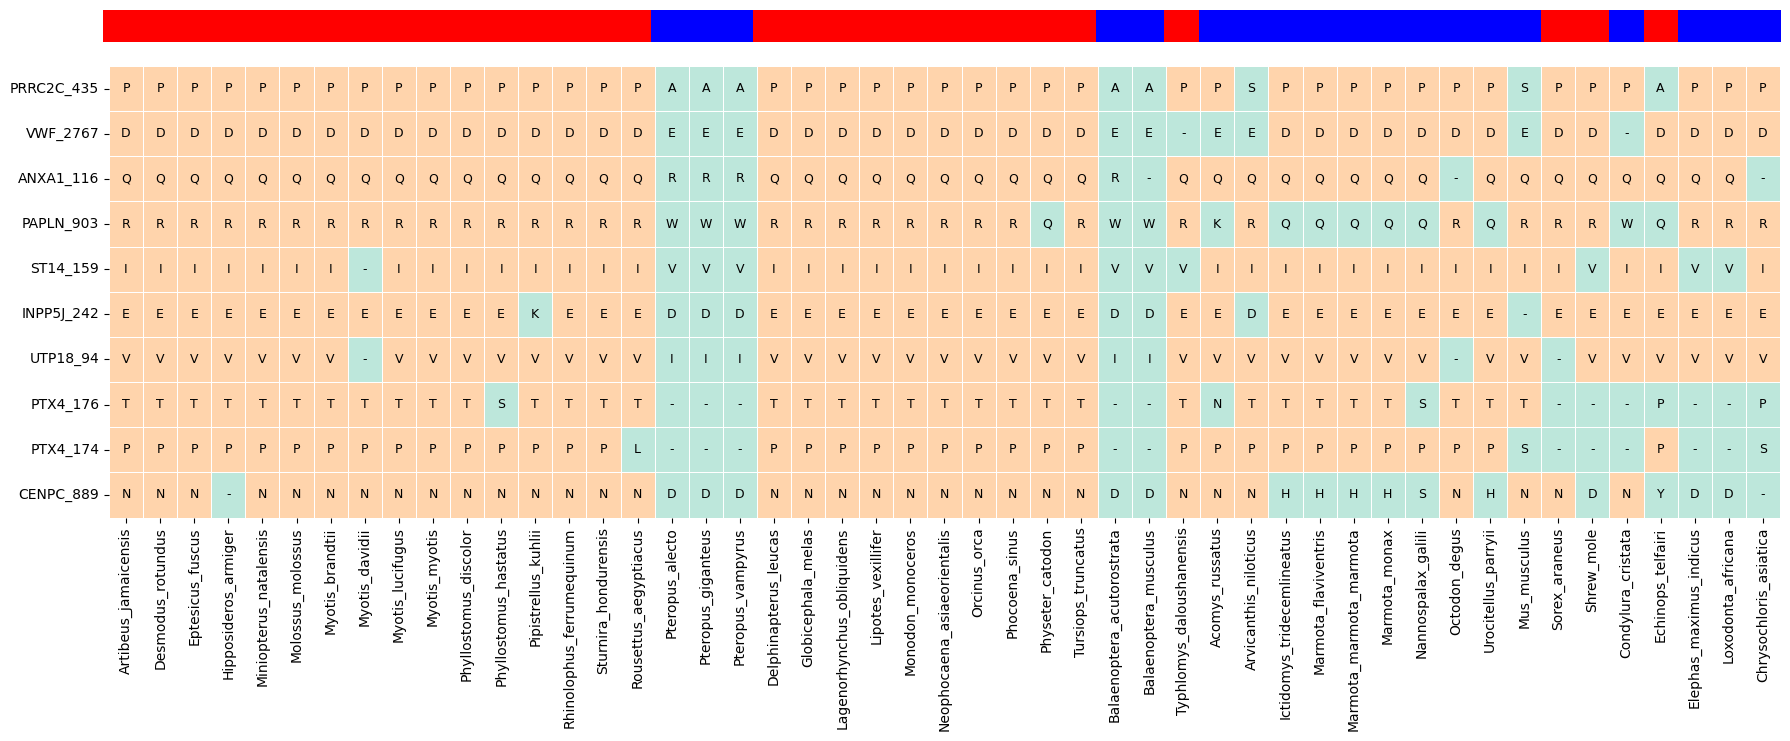

In [6]:


fig, ax = plt.subplots(figsize=(18, 8))

# --- A. 绘制主热力图 ---
sns.heatmap(color_df.T, 
            ax=ax, 
            cmap='icefire', 
            cbar=False, 
            linewidths=0.5, 
            linecolor='white',
            yticklabels=True, 
            xticklabels=True)

# --- B. 添加文本 ---
heat_data = color_df.T.values
text_data = text_df.T 

for i in range(heat_data.shape[0]):
    for j in range(heat_data.shape[1]):
        text_val = text_data[i, j]
        bg_val = heat_data[i, j]
        # text_color = 'white' if bg_val == 1 else 'black'
        text_color = 'black'
        
        ax.text(j + 0.5, i + 0.5, str(text_val), 
                ha='center', va='center', 
                fontsize=9, 
                color=text_color)

ax_bar = fig.add_axes([0.06, 0.88, 0.932, 0.04])

colors = ["#0000FF", "#FF0000"] # Blue for 0, Red for 1
cmap_custom = ListedColormap(colors)
label_array = label.reshape(1, -1).astype(float)

# 3. 关键参数设置：
# vmin=0, vmax=1: 强制颜色映射的范围锁定在 0 到 1 之间，防止数据波动导致颜色偏移
sns.heatmap(label_array, 
            ax=ax_bar, 
            cmap=cmap_custom,      # 使用自定义的红蓝图
            vmin=0, vmax=1,        # 锁定颜色范围
            cbar=False, 
            linewidths=0,
            xticklabels=False, 
            yticklabels=False)

plt.setp(ax.get_yticklabels(), rotation=0, ha="right")

plt.tight_layout()
plt.subplots_adjust(top=0.85) 
plt.savefig('clade_diff.svg', bbox_inches='tight')
plt.show()

In [5]:
# display_df.to_csv('display_clade_diff_better.csv')

### 结果2 

在这两个谱系上删选出的趋同，谱系内回声 > 非回声， 谱系间趋同不保证

In [11]:
top_5000 = nmi_df.index[:5000]

data = raw_data.loc[raw_meta.index[raw_meta['label'] != 2],top_5000]
meta = raw_meta.loc[data.index, :]
## get eco mutation 

# idx = meta['order_chinese_new'].isin(['鲸目','翼手目','真盲缺目','非洲兽目']) & meta['label'] == 1
idx = meta['order_chinese_new'].isin(['鲸目','翼手目']) & meta['label'] == 1
species_list = meta.index[idx].to_list()
eco_data = data.loc[species_list,]
eco_mutation = eco_data.mode().iloc[0,:].values



In [12]:
plot_df = meta.copy()
for i in range(50,5050,50):
    plot_df.loc[:,f'top_{i}'] = (data == eco_mutation).iloc[:,:i].sum(axis = 1)
plot_df.loc[:,'en_idx'] = plot_df.index.values
plot_df.index = plot_df['species_chinese'].values
plot_df.drop('中华树鼩', axis = 0, inplace = True)

/tmp/ipykernel_1516290/109608991.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  plot_df.loc[:,f'top_{i}'] = (data == eco_mutation).iloc[:,:i].sum(axis = 1)
/tmp/ipykernel_1516290/109608991.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  plot_df.loc[:,f'top_{i}'] = (data == eco_mutation).iloc[:,:i].sum(axis = 1)
/tmp/ipykernel_1516290/109608991.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all colum

In [32]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import os

# save_dir = '两支趋同_修改_count'
# os.makedirs(save_dir, exist_ok = True)

# for k_value in [50,100,200,300,500,1000]:
#     # 选择要绘制的 top_k 列（例如 top_500）
#     # k_value = 1000 # 可以修改为想要的值，如 50, 100, 500, 1000 等
#     value_col = f'top_{k_value}' 

#     # 按 order_chinese_new 和 label 排序，确保同组的在一起
#     plot_df_sorted = plot_df.sort_values(['order_chinese_new', 'label', value_col], 
#                                         ascending=[True, False, False])

#     # 设置颜色映射：0=非回声定位(蓝色), 1=回声定位(红色)
#     color_map = {0.0: '#3498db', 1.0: '#e74c3c'}  # 蓝色和红色
#     colors = [color_map.get(label, '#95a5a6') for label in plot_df_sorted['label']]

#     # 创建图形
#     fig, ax = plt.subplots(figsize=(18, 6))


#     bars = ax.bar(range(len(plot_df_sorted)), 
#                 plot_df_sorted[value_col], 
#                 color=colors,
#                 edgecolor='black',
#                 linewidth=0.3)

#     ax.set_xticks(range(len(plot_df_sorted)))
#     ax.set_xticklabels(plot_df_sorted.index, rotation=90, ha='center', fontsize=8)


#     orders = plot_df_sorted['order_chinese_new'].unique()
#     order_positions = []
#     for order in orders:
#         idx = plot_df_sorted['order_chinese_new'] == order
#         positions = plot_df_sorted.index[idx]
#         start_pos = list(plot_df_sorted.index).index(positions[0])
#         end_pos = list(plot_df_sorted.index).index(positions[-1])
#         center_pos = (start_pos + end_pos) / 2
#         order_positions.append((order, center_pos, start_pos, end_pos))

#     # 在顶部添加order标签
#     for order, center, start, end in order_positions:
#         ax.text(center, ax.get_ylim()[1] * 1.02, order, 
#                 ha='center', va='bottom', fontsize=10, fontweight='bold')
#         # 添加分组竖线
#         if start > 0:
#             ax.axvline(x=start-0.5, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)

#     # 设置标题和标签
#     # ax.set_xlabel('物种', fontsize=12)
#     ax.set_ylabel(f'Top {k_value} 匹配数', fontsize=12)
#     # ax.set_title(f'各物种在 Top {k_value} 位点的匹配数分布\n(按目分组，红色=回声定位，蓝色=非回声定位)', fontsize=14)

#     # 添加图例
#     from matplotlib.patches import Patch
#     legend_elements = [Patch(facecolor='#e74c3c', edgecolor='black', label='回声定位 (1)'),
#                     Patch(facecolor='#3498db', edgecolor='black', label='非回声定位 (0)')]
#     ax.legend(handles=legend_elements, loc='upper left')

#     plt.tight_layout()
#     plt.subplots_adjust(top=0.9)  # 为顶部分组标签留出空间
#     plt.savefig(os.path.join(save_dir, f'{k_value}_count.svg'), bbox_inches = 'tight')    
#     plt.show()


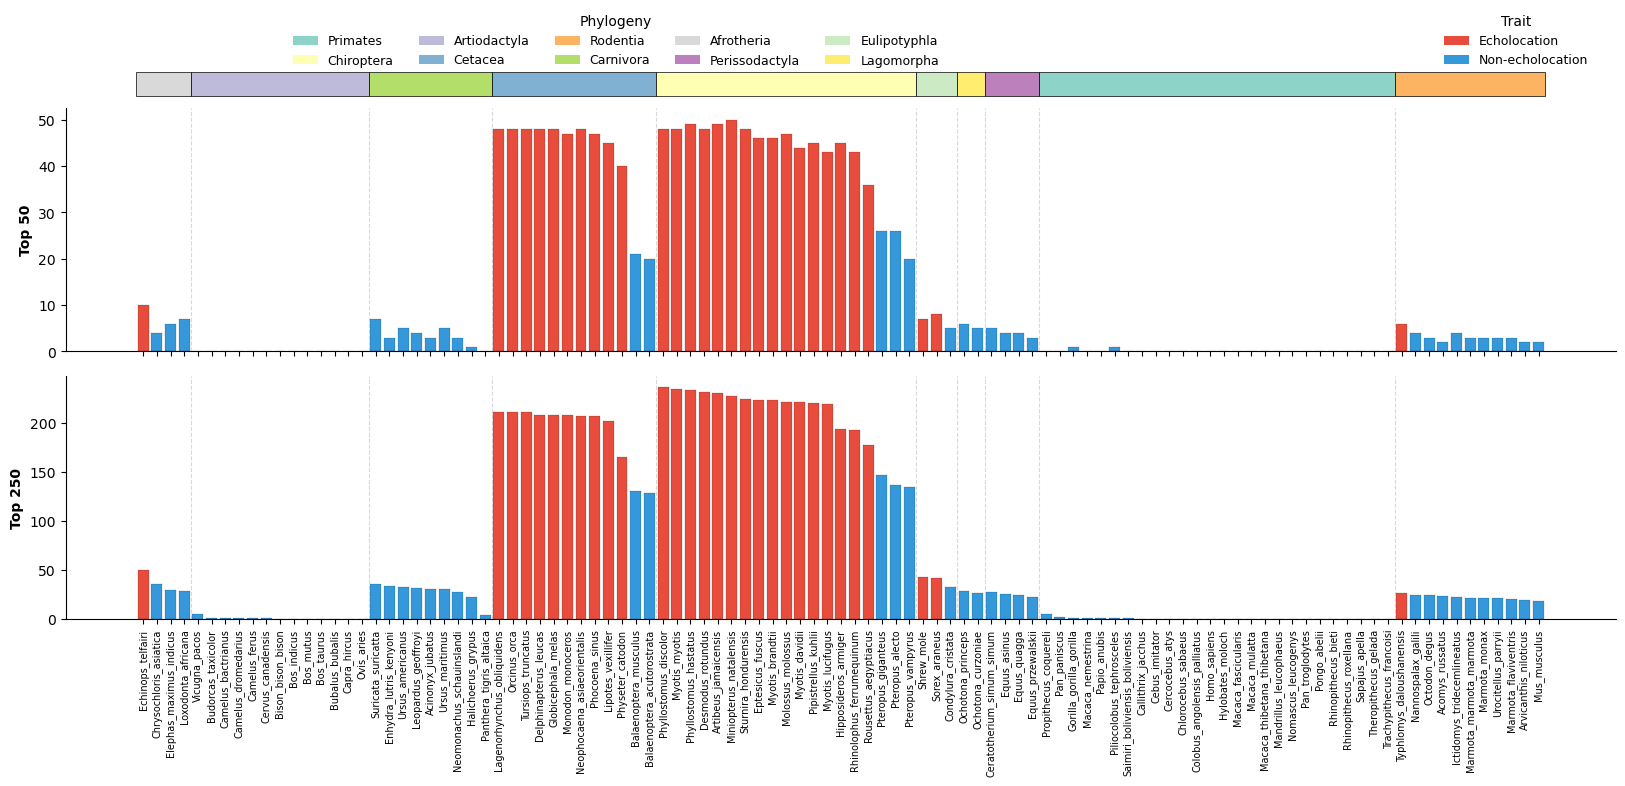

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
import numpy as np
from matplotlib.patches import Patch, Rectangle

# 1. 映射与颜色配置
order_map_en = {
    '灵长目': 'Primates', '翼手目': 'Chiroptera', '偶蹄目': 'Artiodactyla',
    '鲸目': 'Cetacea', '啮齿目': 'Rodentia', '食肉目': 'Carnivora',
    '非洲兽目': 'Afrotheria', '奇蹄目': 'Perissodactyla', 
    '真盲缺目': 'Eulipotyphla', '兔形目': 'Lagomorpha'
}

# 使用科研配色方案 (Set3 或其他高区分度色板)
order_names_en = list(order_map_en.values())
cmap_orders = plt.get_cmap('Set3', len(order_names_en))
order_color_dict = {name: cmap_orders(i) for i, name in enumerate(order_names_en)}

# 2. 数据预处理
plot_df['order_en'] = plot_df['order_chinese_new'].map(order_map_en)
plot_df.index = plot_df['en_idx'].values

plot_df = plot_df.rename(index={'ZWS': 'Typhlomys_daloushanensis'})
plot_df = plot_df.rename(index={'shrew_mole': 'Shrew_mole'})
plot_df = plot_df.rename(index={'Neophocaena_asiaeorientalis_asiaeorientalis': 'Neophocaena_asiaeorientalis',
                                'Balaenoptera_acutorostrata_scammoni': 'Balaenoptera_acutorostrata'})

save_dir = 'convergence_count_plots_en'
os.makedirs(save_dir, exist_ok=True)

k_values = [50,250] # [50,100,200,500]
fig, axes = plt.subplots(len(k_values), 1, figsize=(20, 7), sharex=True)

# 3. 排序 (以最后一张图展示的顺序为准，确保四张图一致)
# 我们统一按照最后一个 K 值的数值大小来对组内进行排序
last_k_col = f'top_{k_values[-1]}'
plot_df_sorted = plot_df.sort_values(['order_en', 'label', last_k_col], 
                                    ascending=[True, False, False])

for i, k_value in enumerate(k_values):
    ax = axes[i]
    value_col = f'top_{k_value}'
    
    trait_colors = ['#e74c3c' if l == 1.0 else '#3498db' for l in plot_df_sorted['label']]
    
    # 绘制柱状图
    ax.bar(range(len(plot_df_sorted)), plot_df_sorted[value_col], 
           color=trait_colors, edgecolor='black', linewidth=0.1)
    
    # 辅助分割线：穿过所有子图
    for o_en in plot_df_sorted['order_en'].unique():
        idx_mask = plot_df_sorted['order_en'] == o_en
        start = np.where(idx_mask)[0][0]
        if start > 0:
            ax.axvline(x=start - 0.5, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)

    # 4. 只在最顶部的图中绘制一条 Color Bar
    if i == 0:
        ymin, ymax = ax.get_ylim()
        bar_height = (ymax - ymin) * 0.10  # 适当加厚
        bar_y_pos = ymax + (ymax - ymin) * 0.05
        
        for o_en in plot_df_sorted['order_en'].unique():
            idx_mask = plot_df_sorted['order_en'] == o_en
            pos_indices = np.where(idx_mask)[0]
            start, end = pos_indices[0], pos_indices[-1]
            
            rect = Rectangle((start - 0.5, bar_y_pos), end - start + 1, bar_height,
                             facecolor=order_color_dict[o_en], edgecolor='black', 
                             linewidth=0.5, clip_on=False)
            ax.add_patch(rect)

    # 标签优化
    ax.set_ylabel(f'Top {k_value}', fontsize=10, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 5. 设置最底部的 X 轴文字
axes[-1].set_xticks(range(len(plot_df_sorted)))
axes[-1].set_xticklabels(plot_df_sorted.index, rotation=90, fontsize=7)

# 6. 图例修正 (放在画布的最上方中央)
order_legends = [Patch(facecolor=color, label=name) for name, color in order_color_dict.items()]
trait_legends = [Patch(facecolor='#e74c3c', label='Echolocation'),
                 Patch(facecolor='#3498db', label='Non-echolocation')]

# 使用 fig.legend 并手动指定位置，确保不被截断
leg1 = fig.legend(handles=order_legends, title="Phylogeny", 
                  loc='upper center', bbox_to_anchor=(0.4, 1.03), 
                  ncol=5, fontsize=9, title_fontsize=10, frameon=False)

leg2 = fig.legend(handles=trait_legends, title="Trait",
                  loc='upper center', bbox_to_anchor=(0.85, 1.03), 
                  ncol=1, fontsize=9, title_fontsize=10, frameon=False)

# 7. 布局微调：减小垂直间距 (hspace)
plt.subplots_adjust(top=0.88, hspace=0.1, bottom=0.15) 

# # 保存
plt.savefig(os.path.join(save_dir, 'shared_x_convergence_plot_50_250.svg'), bbox_inches='tight')
plt.show()